In [1]:
import sys

import matplotlib.pyplot as plt
import nfl_data_py as nfl
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from scipy.stats import pearsonr
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (GridSearchCV, KFold, ParameterGrid,
                                     ParameterSampler, RandomizedSearchCV,
                                     ShuffleSplit, StratifiedShuffleSplit,
                                     TimeSeriesSplit)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

sys.path.append("../src")
from features.feature_engineering import main as import_data
from models.elo import ELO

/Users/iggysiegel/opt/anaconda3/envs/sports_betting/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def prepare_data(
    data: pd.DataFrame,
    train_seasons: list[int],
    test_seasons: list[int],
    features: list[str]
) -> tuple[
    pd.DataFrame, pd.DataFrame, pd.Series, 
    pd.DataFrame, pd.DataFrame, pd.Series
]:
    """
    Partition a dataset into training and testing sets, dropping rows with missing 
    feature values.

    Args:
        data: Input dataset containing all seasons and target column 'result'.
        train_seasons: List of season values to include in the training set.
        test_seasons: List of season values to include in the testing set.
        features: List of feature column names to use as predictors.

    Returns:
        tuple: Training dataframe, training feature matrix, training target vector,
            testing dataframe, testing feature matrix, testing target vector.

    Todo:
        Add support for standardization and normalization.
    """
    df_train = data[data["season"].isin(train_seasons)].dropna(subset=features)
    df_test = data[data["season"].isin(test_seasons)].dropna(subset=features)

    X_train = df_train[features]
    y_train = df_train["result"]
    X_test = df_test[features]
    y_test = df_test["result"]

    return df_train, X_train, y_train, df_test, X_test, y_test

In [3]:
def get_hyperparams(trial: optuna.Trial, model_class: str) -> dict:
    """ 
    Return hyperparameter search space for the given model.

    Args:
        trial: Optuna trial object.
        model_class: Model class.
    
    Returns:
        dict: Hyperparameter search space.

    Todo:
        Add support for span and revert.
    """
    if model_class == "XGB":
        return {
            "max_depth": trial.suggest_int("max_depth", 1, 5),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.1),
            "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 0.5, 1.0]),
            "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 0.5, 1.0, 5.0]),         
        }

In [4]:
def build_model(model_class: str, hyperparams: dict, early_stopping: bool):
    """
    Initialize a machine learning model with the specified hyperparameters.

    Args:
        model_class: Model class.
        hyperparams: Hyperparameters for the model.
        early_stopping: Whether to include early stopping.

    Returns:
        Initialized machine learning model.
    """
    if model_class == "XGB":
        model_args = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "n_estimators": 2500,
            **hyperparams
        }
        if early_stopping:
            model_args["early_stopping_rounds"] = 50
        return xgb.XGBRegressor(**model_args)

In [ ]:
def cross_validation(model, X: pd.DataFrame, y: pd.Series, seasons: pd.Series) -> tuple[float, int]:
    """
    Perform time-based cross-validation for the given model. For each fold, the model
    is trained on four consecutive seasons and validated on the subsequent season.

    Args:
        model: The machine learning model to evaluate.
        X: Feature matrix.
        y: Target vector.
        seasons: Series indicating the season for each row in X.

    Returns:
        tuple: The mean RMSE score and the median number of boosting iterations.
    """
    scores = []
    best_iterations = []

    all_seasons = list(range(seasons.min(), seasons.max() + 1))
    for i in range(len(all_seasons) - 4):
        train_seasons = all_seasons[i : i + 4]
        val_seasons = all_seasons[i + 4]

        train_idx = seasons[seasons.isin(train_seasons)].index
        val_idx = seasons[seasons.isin([val_seasons])].index
        X_train, y_train = X.loc[train_idx], y.loc[train_idx]
        X_val, y_val = X.loc[val_idx], y.loc[val_idx]

        try:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        except TypeError:
            model.fit(X_train, y_train)

        preds = model.predict(X_val)
        rmse = metrics.root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
        if hasattr(model, "best_iteration"):
            best_iterations.append(model.best_iteration)

    best_iterations = int(np.median(best_iterations)) if best_iterations else None
    return float(np.mean(scores)), best_iterations

In [6]:
def objective(
    trial: optuna.Trial,
    X: pd.DataFrame,
    y: pd.Series,
    seasons: pd.Series,
    model_class: str
) -> float:
    """
    Objective function for Optuna hyperparameter optimization.
    
    Args:
        trial: Optuna trial object.
        X: Feature matrix.
        y: Target vector.
        seasons: Series indicating the season for each row in X.
        model_class: Model class.
    
    Returns:
        float: RMSE score.
    """
    hyperparams = get_hyperparams(trial, model_class)
    model = build_model(model_class, hyperparams, early_stopping=True)
    score, best_iteration = cross_validation(model, X, y, seasons)
    if hasattr(model, "best_iteration"):
        trial.set_user_attr("best_iteration", best_iteration)
    return score

In [7]:
def tune_hyperparameters(
    X: pd.DataFrame, 
    y: pd.Series,
    seasons: pd.Series,
    model_class: str, 
    n_trials: int
) -> optuna.Study:
    """
    Run Optuna hyperparameter tuning to minimize the objective function.

    Args:
        X: Feature matrix.
        y: Target vector.
        seasons: Series indicating the season for each row in X.
        model_class: Model class.
        n_trials: Number of optimization trials.

    Returns:
        optuna.Study: Fitted Optuna study containing optimization results.
    """
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, X, y, seasons, model_class), n_trials=n_trials)
    return study

In [8]:
def main(
    data: pd.DataFrame,
    train_seasons: list[int],
    test_seasons: list[int],
    features: list[str],
    model_class: str,
    n_trials: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Main function to prepare data, tune hyperparameters, fit the model, and store
    predictions.

    Args:
        data: Input dataset containing all seasons and target column 'result'.
        train_seasons: List of season values to include in the training set.
        test_seasons: List of season values to include in the testing set.
        features: List of feature column names to use as predictors.
        model_class: Model class.
        n_trials: Number of hyperparameter optimization trials.

    Returns:
        tuple: Training dataframe with predictions, testing dataframe with predictions.
    """
    if model_class not in ["XGB"]:
        raise NotImplementedError(f"Model class not implemented for {model_class}")

    # Prepare data
    df_train, X_train, y_train, df_test, X_test, y_test = prepare_data(
        data, train_seasons, test_seasons, features
    )

    # Tune hyperparameters
    seasons = df_train["season"]
    study = tune_hyperparameters(X_train, y_train, seasons, model_class, n_trials)
    best_params = study.best_params
    best_iteration = study.best_trial.user_attrs.get("best_iteration", None)
    if best_iteration is not None:
        best_params["n_estimators"] = best_iteration

    # Fit model with best hyperparameters
    model = build_model(model_class, best_params, early_stopping=False)
    model.fit(X_train, y_train)

    # Store predictions
    df_train["model_predictions"] = model.predict(X_train)
    df_test["model_predictions"] = model.predict(X_test)

    return df_train, df_test

In [9]:
data = import_data(2010, 2024, span=5)

historical_elos = pd.read_csv("../data/external/historical_elos.csv")
data = ELO(data, historical_elos).data
features = [col for col in data.columns if col not in ["game_id", "season", "week", "home_team", "away_team", "result", "roof", "surface", "attendance", "home_line", "over_under"]]

data.head()

,game_id,season,week,home_team,away_team,result,home_line,over_under,roof,surface,...,ydsnet_mean_adv_away,tackled_for_loss_sum_adv_home,tackled_for_loss_sum_adv_away,yards_after_catch_sum_adv_home,yards_after_catch_sum_adv_away,home_elo,away_elo,home_elo_prob,away_elo_prob,elo_diff
0,20110908_nor_gnb,2011,1,gnb,nor,8.0,-5.0,48.0,outdoors,grass,...,6.686245,-0.107843,0.000000,8.970588,21.147059,1661.483,1562.051,0.720420,0.279580,99.432
1,20110911_phi_ram,2011,1,ram,phi,-18.0,4.0,44.5,indoors,turf,...,1.393940,-0.446078,-0.855392,6.737745,6.928922,1416.520,1551.734,0.400307,0.599693,-135.214
2,20110911_clt_htx,2011,1,htx,clt,27.0,-9.0,44.0,outdoors,grass,...,1.924899,0.213235,0.017157,15.774510,-6.669118,1478.396,1567.700,0.465081,0.534919,-89.304
3,20110911_oti_jax,2011,1,jax,oti,2.0,1.5,38.0,outdoors,grass,...,-6.736981,-0.958333,0.333333,-21.541667,-32.250000,1474.460,1471.892,0.596031,0.403969,2.568
4,20110911_pit_rav,2011,1,rav,pit,28.0,-1.5,37.0,outdoors,turf,...,2.215047,0.325536,0.561404,8.651072,3.403509,1612.017,1606.563,0.600024,0.399976,5.454


In [10]:
df_train, df_test = main(
    data=data,
    train_seasons=list(range(2011, 2024)),
    test_seasons=[2024],
    features=features,
    model_class="XGB",
    n_trials=50
)

[I 2025-10-05 17:15:09,187] A new study created in memory with name: no-name-4d566819-f43d-42b3-85eb-5f437fd08c35
[I 2025-10-05 17:15:11,391] Trial 0 finished with value: 13.204290402789812 and parameters: {'max_depth': 2, 'subsample': 0.7500092580209032, 'colsample_bytree': 0.8939516157006793, 'learning_rate': 0.032502505893465046, 'reg_alpha': 0.0, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.204290402789812.
[I 2025-10-05 17:15:14,240] Trial 1 finished with value: 13.236770486517129 and parameters: {'max_depth': 4, 'subsample': 0.5572143561228099, 'colsample_bytree': 0.8047448015760361, 'learning_rate': 0.03865760801746587, 'reg_alpha': 0.5, 'reg_lambda': 1.0}. Best is trial 0 with value: 13.204290402789812.
[I 2025-10-05 17:15:16,196] Trial 2 finished with value: 13.169079179650623 and parameters: {'max_depth': 1, 'subsample': 0.9769937254825217, 'colsample_bytree': 0.6788162120742107, 'learning_rate': 0.07003175345507509, 'reg_alpha': 0.5, 'reg_lambda': 1.0}. Best is trial 2

Model RMSE: 12.98
Vegas RMSE: 12.67


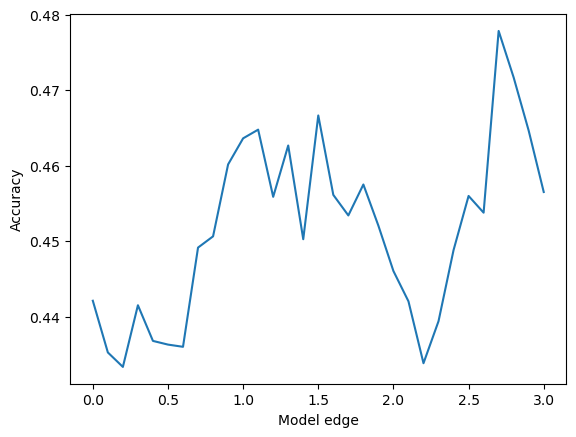

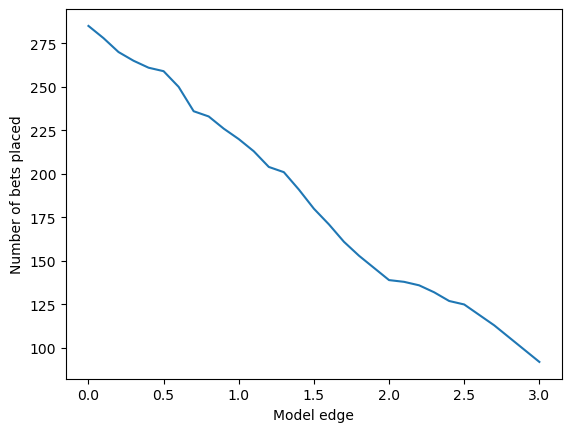

In [11]:
thresholds_list = []
accuracy_list = []
bets_placed_list = []
for threshold in np.arange(0, 3.1, .1):
    bets_placed = 0
    bets_won = 0
    for row in df_test.itertuples():
        if row.model_predictions + threshold < -row.home_line:
            bets_placed += 1
            if row.result < row.home_line:
                bets_won += 1
        elif row.model_predictions > -row.home_line + threshold:
            bets_placed += 1
            if row.result > row.home_line:
                bets_won += 1
        else:
            continue
    thresholds_list.append(threshold)
    accuracy_list.append(bets_won / bets_placed)
    bets_placed_list.append(bets_placed)

model_rmse = metrics.root_mean_squared_error(df_test["result"], df_test["model_predictions"])
vegas_rmse = metrics.root_mean_squared_error(df_test["result"], -df_test["home_line"])
print(f"Model RMSE: {model_rmse:.2f}")
print(f"Vegas RMSE: {vegas_rmse:.2f}")

plt.plot(thresholds_list, accuracy_list)
plt.xlabel("Model edge")
plt.ylabel("Accuracy")
plt.show()

plt.plot(thresholds_list, bets_placed_list)
plt.xlabel("Model edge")
plt.ylabel("Number of bets placed")
plt.show()